# DNN

## 성능 개선을 위해 입력 데이터 분석 => 전처리 후 학습 필요

데이터셋에 따라 입력층과 출력층 정해져있음 

은닉층, 노드 수은 경우에 따라 달라짐 이 수를 잘 지정하면(하이퍼 파라미터) 좋은 성능이 나옴

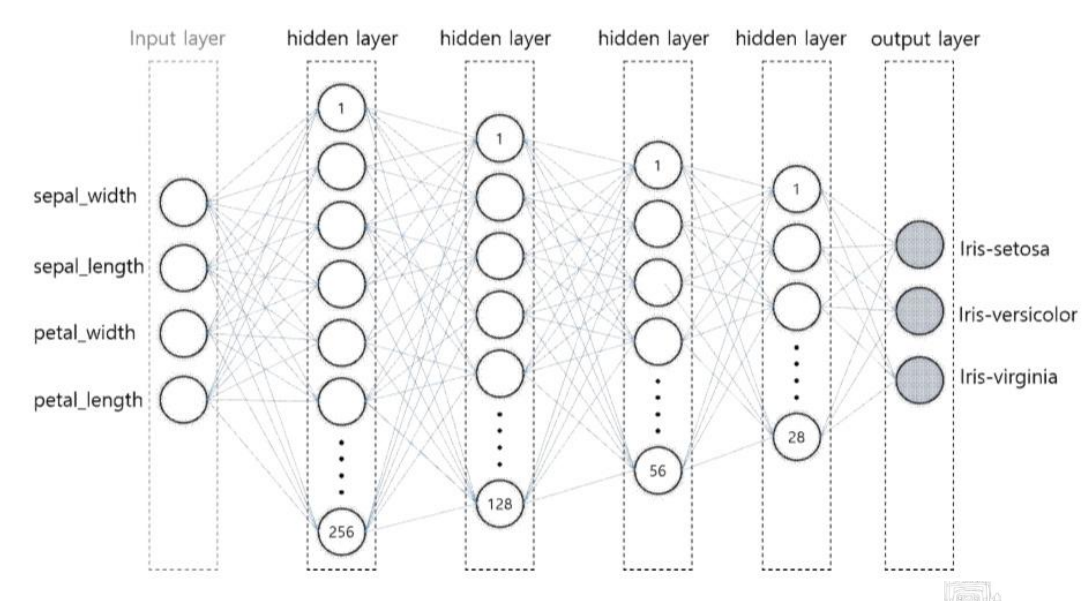

신경망 전체에서 학습해야 할 "파라미터 수 (매개변수 수, parameters)"를 계산 :

(4 * 256 + 256) + (256 * 128 + 128) + (128 * 56 + 56)....

# 로지스틱 회귀 모델 직접 구현

In [43]:
import numpy as np

In [63]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [64]:
def numerical_derivative(f, x): # 수치 미분 함수
    delta_x = 1e-4
    grad = np.zeros_like(x)
    it = np.nditer(x, flags =['multi_index'], op_flags = ['readwrite'])
    
    while not it.finished:
        idx = it.multi_index
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + delta_x
        fx1 = f(x) #
        x[idx] = tmp_val - delta_x
        fx2 = f(x)
        grad[idx] = (fx1 - fx2) / (2 * delta_x)
        x[idx] = tmp_val
        it.iternext()

    return grad

In [82]:
class LogicGate:
    def __init__(self, gate_name, xdata, tdata):
        self.name = gate_name
        self.xdata = xdata.reshape(4, 2)
        self.tdata = tdata.reshape(4, 1)

        self.W = np.random.rand(self.xdata.shape[1], 1)
        self.b = np.random.rand(1)
        self.learning_rate = 1e-2

    def loss_func(self):
        delta = 1e-7
        z = np.dot(self.xdata, self.W) + self.b
        y = sigmoid(z)

        return -np.sum(self.tdata * np.log(y + delta) + (1 - self.tdata) * np.log((1 - y) + delta))

    def train(self):
        f = lambda x : self.loss_func()
        print("Initial loss value = ", self.loss_func())
        for step in range(18001):
            self.W -= self.learning_rate * numerical_derivative(f, self.W)
            self.b -= self.learning_rate * numerical_derivative(f, self.b)
            if (step % 1000 == 0):
                print("step = ", step, "loss value = ", self.loss_func())

    def predict(self, input_data):
        z = np.dot(input_data, self.W) + self.b
        y = sigmoid(z)

        if y > 0.5:
            result = 1
        else:
            result = 0

        return y, result

    def accuracy(self, test_xdata, test_tdata):
        matched_list = []
        not_matched_list = []

        for index in range(len(xdata)):
            (real_val, logical_val) = self.predict(test_xdata[index])
            if logical_val == test_tdata[index]:
                matched_list.append(index)
            else:
                not_matched_list.append(index)

        accuracty_val = len(matched_list) / len(test_xdata)

        return accuracty_val

# AND

In [83]:
xdata =np.array([[0, 0], [0,1], [1,0], [1,1]])
tdata = np.array([0, 0, 0, 1])
AND_obj = LogicGate("AND_GATE", xdata, tdata)
AND_obj.train()

Initial loss value =  3.3070662832712254
step =  0 loss value =  3.272311566922722
step =  1000 loss value =  0.9745953581671656
step =  2000 loss value =  0.6464576843908316
step =  3000 loss value =  0.4836417317165288
step =  4000 loss value =  0.3852863294934612
step =  5000 loss value =  0.31944268245626417
step =  6000 loss value =  0.2723639919160516
step =  7000 loss value =  0.2370939180973862
step =  8000 loss value =  0.20972644194106266
step =  9000 loss value =  0.18789959203881887
step =  10000 loss value =  0.1701024546545093
step =  11000 loss value =  0.15532456847496756
step =  12000 loss value =  0.14286524538738204
step =  13000 loss value =  0.13222374356980182
step =  14000 loss value =  0.12303296951872275
step =  15000 loss value =  0.11501785397878769
step =  16000 loss value =  0.10796833095327282
step =  17000 loss value =  0.10172128344676906
step =  18000 loss value =  0.0961481730318885


In [84]:
# 학습 후 검증
test_xdata = np.array([ [0,0], [0,1], [1,0], [1,1] ])
for input_data in test_xdata:
    (sigmoid_val, logical_val) = AND_obj.predict(input_data)
    print(input_data, "=", logical_val)

print('----------------------')
test_tdata = np.array([0,0,0,1])
accuracy_ret = AND_obj.accuracy(test_xdata, test_tdata)
print("Accuracy => ", accuracy_ret)

[0 0] = 0
[0 1] = 0
[1 0] = 0
[1 1] = 1
----------------------
Accuracy =>  1.0


# OR게이트 학습 진행

In [85]:
xdata =np.array([[0, 0], [0, 1], [1,0], [1,1]])
tdata = np.array([0, 1, 1, 1])
OR_obj = LogicGate("OR_GATE", xdata, tdata)
OR_obj.train()

Initial loss value =  2.09810672445884
step =  0 loss value =  2.086840456077259
step =  1000 loss value =  0.7082941001442971
step =  2000 loss value =  0.42724698935117333
step =  3000 loss value =  0.301415285312025
step =  4000 loss value =  0.2312320222891166
step =  5000 loss value =  0.18687348599780718
step =  6000 loss value =  0.15646031553741968
step =  7000 loss value =  0.13438063770311554
step =  8000 loss value =  0.1176570555363762
step =  9000 loss value =  0.1045702491180036
step =  10000 loss value =  0.09406100989229645
step =  11000 loss value =  0.08544258879530738
step =  12000 loss value =  0.07825091034002284
step =  13000 loss value =  0.07216145923821722
step =  14000 loss value =  0.06694069277441334
step =  15000 loss value =  0.06241637011732021
step =  16000 loss value =  0.058458749691679794
step =  17000 loss value =  0.05496828801983822
step =  18000 loss value =  0.05186736597896462


In [86]:
# 학습 후 검증
test_xdata = np.array([ [0,0], [0,1], [1,0], [1,1] ])
for input_data in test_xdata:
    (sigmoid_val, logical_val) = OR_obj.predict(input_data)
    print(input_data, "=", logical_val)

print('----------------------')
test_tdata = np.array([0,1,1,1])
accuracy_ret = OR_obj.accuracy(test_xdata, test_tdata)
print("Accuracy => ", accuracy_ret)

[0 0] = 0
[0 1] = 1
[1 0] = 1
[1 1] = 1
----------------------
Accuracy =>  1.0


# NAND

In [87]:
xdata =np.array([[0, 0], [0, 1], [1,0], [1,1]])
tdata = np.array([1, 1, 1, 0])
NAND_obj = LogicGate("NAND_GATE", xdata, tdata)
NAND_obj.train()

Initial loss value =  2.966479145307256
step =  0 loss value =  2.9565791907421097
step =  1000 loss value =  1.0502386845546696
step =  2000 loss value =  0.6780591465666497
step =  3000 loss value =  0.501306054816643
step =  4000 loss value =  0.39657833349562843
step =  5000 loss value =  0.32726698094142137
step =  6000 loss value =  0.2780923335100181
step =  7000 loss value =  0.24146079189521674
step =  8000 loss value =  0.2131605869876141
step =  9000 loss value =  0.1906678182299968
step =  10000 loss value =  0.1723792810571817
step =  11000 loss value =  0.15722881403968247
step =  12000 loss value =  0.14448052313369159
step =  13000 loss value =  0.1336105475606388
step =  14000 loss value =  0.12423611527138549
step =  15000 loss value =  0.11607122728853311
step =  16000 loss value =  0.10889801433691376
step =  17000 loss value =  0.10254767068620746
step =  18000 loss value =  0.0968874335340352


In [88]:
# 학습 후 검증
test_xdata = np.array([ [0,0], [0,1], [1,0], [1,1] ])
for input_data in test_xdata:
    (sigmoid_val, logical_val) = NAND_obj.predict(input_data)
    print(input_data, "=", logical_val)

print('----------------------')
test_tdata = np.array([1, 1, 1, 0])
accuracy_ret = NAND_obj.accuracy(test_xdata, test_tdata)
print("Accuracy => ", accuracy_ret)

[0 0] = 1
[0 1] = 1
[1 0] = 1
[1 1] = 0
----------------------
Accuracy =>  1.0


# XOR

In [89]:
xdata =np.array([[0, 0], [0, 1], [1,0], [1,1]])
tdata = np.array([0, 1, 1, 0])
XOR_obj = LogicGate("XOR_GATE", xdata, tdata)
XOR_obj.train()

Initial loss value =  3.193225750584614
step =  0 loss value =  3.181823151212498
step =  1000 loss value =  2.772721360499042
step =  2000 loss value =  2.7725903257736304
step =  3000 loss value =  2.7725880029086367
step =  4000 loss value =  2.772587925541534
step =  5000 loss value =  2.7725879223800645
step =  6000 loss value =  2.772587922245851
step =  7000 loss value =  2.7725879222401177
step =  8000 loss value =  2.7725879222398726
step =  9000 loss value =  2.772587922239862
step =  10000 loss value =  2.772587922239862
step =  11000 loss value =  2.772587922239862
step =  12000 loss value =  2.772587922239862
step =  13000 loss value =  2.7725879222398615
step =  14000 loss value =  2.7725879222398615
step =  15000 loss value =  2.7725879222398615
step =  16000 loss value =  2.7725879222398615
step =  17000 loss value =  2.7725879222398615
step =  18000 loss value =  2.7725879222398615


In [90]:
# 학습 후 검증
test_xdata = np.array([ [0,0], [0,1], [1,0], [1,1] ])
for input_data in test_xdata:
    (sigmoid_val, logical_val) = XOR_obj.predict(input_data)
    print(input_data, "=", logical_val)

print('----------------------')
test_tdata = np.array([0, 1, 1, 0])
accuracy_ret = XOR_obj.accuracy(test_xdata, test_tdata)
print("Accuracy => ", accuracy_ret)

[0 0] = 1
[0 1] = 1
[1 0] = 1
[1 1] = 0
----------------------
Accuracy =>  0.75


In [ ]:
# 과제

In [112]:
xdata =np.array([[0, 0], [0, 1], [1,0], [1,1]])
tdata = np.array([1, 1, 1, 0])
NAND_obj = LogicGate("NAND_GATE", xdata, tdata)
NAND_obj.train()

Initial loss value =  2.800067183642997
step =  0 loss value =  2.792973639743135
step =  1000 loss value =  1.0478982316403993
step =  2000 loss value =  0.6770942702891571
step =  3000 loss value =  0.5007725819246346
step =  4000 loss value =  0.39623955491366525
step =  5000 loss value =  0.3270332650728758
step =  6000 loss value =  0.2779217610054132
step =  7000 loss value =  0.24133106756181294
step =  8000 loss value =  0.21305876010713665
step =  9000 loss value =  0.19058585955716395
step =  10000 loss value =  0.1723119543210024
step =  11000 loss value =  0.15717256285403586
step =  12000 loss value =  0.14443284993315558
step =  13000 loss value =  0.13356964845616337
step =  14000 loss value =  0.1242006558666219
step =  15000 loss value =  0.11604019991503858
step =  16000 loss value =  0.10887064424483789
step =  17000 loss value =  0.1025233527043016
step =  18000 loss value =  0.09686568827089169


In [113]:
# 학습 후 검증
nand_result = []
test_xdata = np.array([ [0,0], [0,1], [1,0], [1,1] ])
for input_data in test_xdata:
    (sigmoid_val, logical_val) = NAND_obj.predict(input_data)
    nand_result.append(logical_val)
    print(input_data, "=", logical_val)

print('----------------------')
test_tdata = np.array([0, 1, 1, 0])
accuracy_ret = NAND_obj.accuracy(test_xdata, test_tdata)
print("Accuracy => ", accuracy_ret)

[0 0] = 1
[0 1] = 1
[1 0] = 1
[1 1] = 0
----------------------
Accuracy =>  0.75


In [114]:
xdata =np.array([[0, 0], [0, 1], [1,0], [1,1]])
tdata = np.array([0, 1, 1, 1])
OR_obj = LogicGate("OR_GATE", xdata, tdata)
OR_obj.train()

Initial loss value =  1.794137755456347
step =  0 loss value =  1.7910729904674956
step =  1000 loss value =  0.7099780769546961
step =  2000 loss value =  0.42783528684481037
step =  3000 loss value =  0.3017111099216487
step =  4000 loss value =  0.23140860879921019
step =  5000 loss value =  0.18699018716977875
step =  6000 loss value =  0.15654287815062062
step =  7000 loss value =  0.13444198141646524
step =  8000 loss value =  0.11770434986237456
step =  9000 loss value =  0.1046077800165622
step =  10000 loss value =  0.09409149122969938
step =  11000 loss value =  0.0854678196946995
step =  12000 loss value =  0.07827212909607417
step =  13000 loss value =  0.07217954519369128
step =  14000 loss value =  0.06695628710258325
step =  15000 loss value =  0.06242995104762389
step =  16000 loss value =  0.05847068099624333
step =  17000 loss value =  0.054978851205647765
step =  18000 loss value =  0.051876782221826116


In [115]:
# 학습 후 검증
or_result = []
test_xdata = np.array([ [0,0], [0,1], [1,0], [1,1] ])
for input_data in test_xdata:
    (sigmoid_val, logical_val) = OR_obj.predict(input_data)
    or_result.append(logical_val)
    print(input_data, "=", logical_val)

print('----------------------')
test_tdata = np.array([0,1,1,1])
accuracy_ret = OR_obj.accuracy(test_xdata, test_tdata)
print("Accuracy => ", accuracy_ret)

[0 0] = 0
[0 1] = 1
[1 0] = 1
[1 1] = 1
----------------------
Accuracy =>  1.0


In [116]:
print(nand_result)
print(or_result)

[1, 1, 1, 0]
[0, 1, 1, 1]


In [117]:
xdata = np.array(list(zip(nand_result, or_result)))
tdata = np.array([0, 1, 1, 0])
XOR_obj = LogicGate("XOR_GATE", xdata, tdata)
XOR_obj.train()

Initial loss value =  3.414692860728479
step =  0 loss value =  3.3948712526201903
step =  1000 loss value =  1.4099847266954035
step =  2000 loss value =  0.8645733221031795
step =  3000 loss value =  0.6069578931209727
step =  4000 loss value =  0.4623898622908186
step =  5000 loss value =  0.37136201465772195
step =  6000 loss value =  0.30931168150610855
step =  7000 loss value =  0.264524008047003
step =  8000 loss value =  0.2307796205945603
step =  9000 loss value =  0.20449664997316372
step =  10000 loss value =  0.18347695646429998
step =  11000 loss value =  0.16630132866930555
step =  12000 loss value =  0.15201471104705946
step =  13000 loss value =  0.13995190678009733
step =  14000 loss value =  0.12963597314694825
step =  15000 loss value =  0.12071637065006188
step =  16000 loss value =  0.11292989435689132
step =  17000 loss value =  0.10607519606869652
step =  18000 loss value =  0.09999570116825497


In [118]:
# 학습 후 검증
test_xdata = np.array(list(zip(nand_result, or_result)))
for input_data in test_xdata:
    (sigmoid_val, logical_val) = XOR_obj.predict(input_data)
    print(input_data, "=", logical_val)

print('-----------------------------------')
test_tdata = np.array([0, 1, 1, 0])
accuracy_ret = XOR_obj.accuracy(test_xdata, test_tdata)
print("Accuracy => ", accuracy_ret)

[1 0] = 0
[1 1] = 1
[1 1] = 1
[0 1] = 0
-----------------------------------
Accuracy =>  1.0
